In [1]:
"""
Created on Sun Jul 27 12:29:52 2025

@author: huzefa
"""

'\nCreated on Sun Jul 27 12:29:52 2025\n\n@author: huzefa\n'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
#Importing data
irisData=pd.read_csv('../Datasets/Iris_data.csv')

In [4]:
#Info of data
irisData.info()
print(irisData.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa


In [5]:
#Dropping Id column
irisData=irisData.drop('Id',axis=1)
print(irisData.head())

   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0            5.1           3.5            1.4           0.2  Iris-setosa
1            4.9           3.0            1.4           0.2  Iris-setosa
2            4.7           3.2            1.3           0.2  Iris-setosa
3            4.6           3.1            1.5           0.2  Iris-setosa
4            5.0           3.6            1.4           0.2  Iris-setosa


In [6]:
#Sorting the columns alphabetically
inputColumns=list(irisData.iloc[:,:4].columns)
inputColumns.sort()
inputData=irisData[inputColumns]
print(inputData.head())

   PetalLengthCm  PetalWidthCm  SepalLengthCm  SepalWidthCm
0            1.4           0.2            5.1           3.5
1            1.4           0.2            4.9           3.0
2            1.3           0.2            4.7           3.2
3            1.5           0.2            4.6           3.1
4            1.4           0.2            5.0           3.6


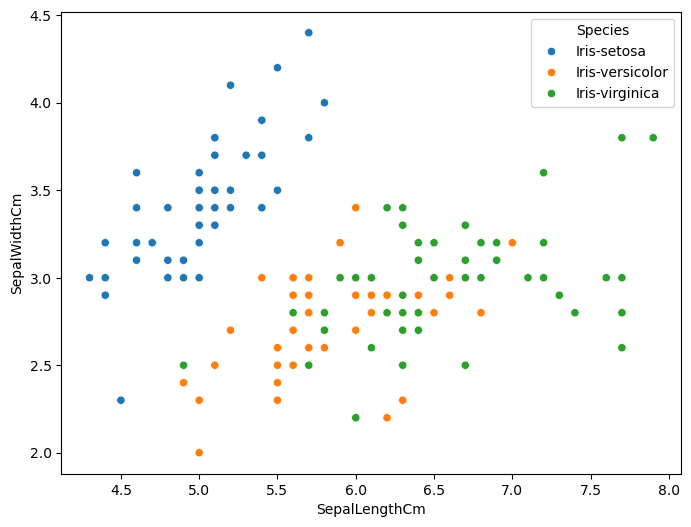

In [7]:
#Plotting a scatter plot of 2 variables from irisData
plt.subplots(figsize=(8,6))
sns.scatterplot(x='SepalLengthCm',y='SepalWidthCm',hue='Species',data=irisData)
plt.show()

In [8]:
#Scaling data to standard
scaler=StandardScaler(with_std=False)
inputData=scaler.fit_transform(inputData)
inputData=pd.DataFrame(inputData,columns=inputColumns)
print(inputData.head())

   PetalLengthCm  PetalWidthCm  SepalLengthCm  SepalWidthCm
0      -2.358667     -0.998667      -0.743333         0.446
1      -2.358667     -0.998667      -0.943333        -0.054
2      -2.458667     -0.998667      -1.143333         0.146
3      -2.258667     -0.998667      -1.243333         0.046
4      -2.358667     -0.998667      -0.843333         0.546


In [9]:
#Computing covariance using scaled data
covMat=inputData.cov()
print(covMat)

               PetalLengthCm  PetalWidthCm  SepalLengthCm  SepalWidthCm
PetalLengthCm       3.113179      1.296387       1.273682     -0.321713
PetalWidthCm        1.296387      0.582414       0.516904     -0.117981
SepalLengthCm       1.273682      0.516904       0.685694     -0.039268
SepalWidthCm       -0.321713     -0.117981      -0.039268      0.188004


In [10]:
#Computing eigenvectors and eigenvalues of covariance matrix
eigVal, eigVec= np.linalg.eig(covMat.values)
eigPairs = [(np.abs(eigVal[i]), eigVec[:,i])for i in range(len(eigVal))]
print(eigPairs)

[(4.224840768320115, array([ 0.85657211,  0.35884393,  0.36158968, -0.08226889])), (0.24224357162751567, array([ 0.1757674 ,  0.07470647, -0.65653988, -0.72971237])), (0.023683027126002103, array([-0.47971899,  0.75112056,  0.31725455, -0.32409435])), (0.0785239080941547, array([ 0.07252408,  0.54906091, -0.58099728,  0.59641809]))]


In [11]:
#Sorting eigPairs in descending order based on the eigen values
eigPairs.sort(key = lambda x: x[0], reverse=True)
#false for ascending order
print('Eigenvalues in descending order:')
for i in eigPairs:
    print(i[0])

Eigenvalues in descending order:
4.224840768320115
0.24224357162751567
0.0785239080941547
0.023683027126002103


In [12]:
#Setting threshold as '95% variance'
threshold = 0.95
#Computing number of PCS required to captured specified variance
print('Explained variance in percentage:\n')
cumulativeVariance = 0.0
count = 0
eigvSum = np.sum(eigVal)
for i,j in enumerate(eigPairs):
    varianceExplained = (j[0]/eigvSum).real
    print('eigenvalue {}: {}'.format(i+1, varianceExplained*100 ))
    cumulativeVariance += varianceExplained
    count = count+1
    if (cumulativeVariance>=threshold):
        break
print('\nCumulative variance=',cumulativeVariance*100)
print('Total no. of eig vecs =',len(eigVec),'\nselected no. of eig vecs =',count)

Explained variance in percentage:

eigenvalue 1: 92.46162071742681
eigenvalue 2: 5.3015567850535055

Cumulative variance= 97.76317750248033
Total no. of eig vecs = 4 
selected no. of eig vecs = 2


In [13]:
#Selecting required PCs based on the count - projection matrix w=d*k
reducedDimension = np.zeros((len(eigVec),count))
for i in range(count):
    reducedDimension[:,i]= eigPairs[i][1]

In [14]:
#Projecting the scaled data onto the reduced space (using eigen vectors)
projectedData = inputData.values.dot(reducedDimension)
projectedDataframe = pd.DataFrame(projectedData,
columns=['PC1','PC2'])
projectedDataframeWithClassInfo = pd.concat([projectedDataframe,
irisData.Species],axis=1)

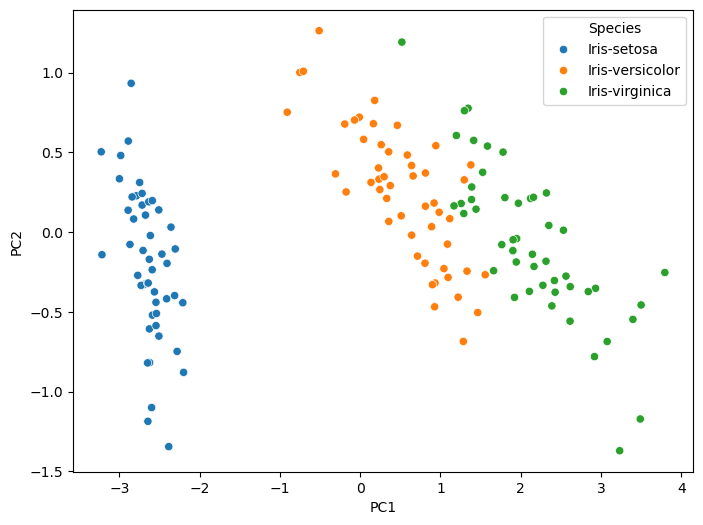

In [15]:
#Plotting PCs
plt.subplots(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Species', data=projectedDataframeWithClassInfo)
plt.show()

In [16]:
#Using SVD
u, s, v = np.linalg.svd(inputData) #decomposing using SVD
expVar=s**2/np.sum(s**2)*100 # Explained variance by each eigen value/PC
pc=irisData[inputColumns].dot(v.T) # Rotating and trnsforming from sample space to feature space
pc.columns=['PC1','PC2','PC3','PC4']
pc['Species']= irisData.Species
print(pc.head())

        PC1       PC2       PC3       PC4      Species
0  2.827136 -5.641331  0.664277  0.037715  Iris-setosa
1  2.795952 -5.145167  0.846287 -0.060882  Iris-setosa
2  2.621524 -5.177378  0.618056  0.019416  Iris-setosa
3  2.764906 -5.003599  0.605093  0.114676  Iris-setosa
4  2.782750 -5.648648  0.546535  0.101849  Iris-setosa


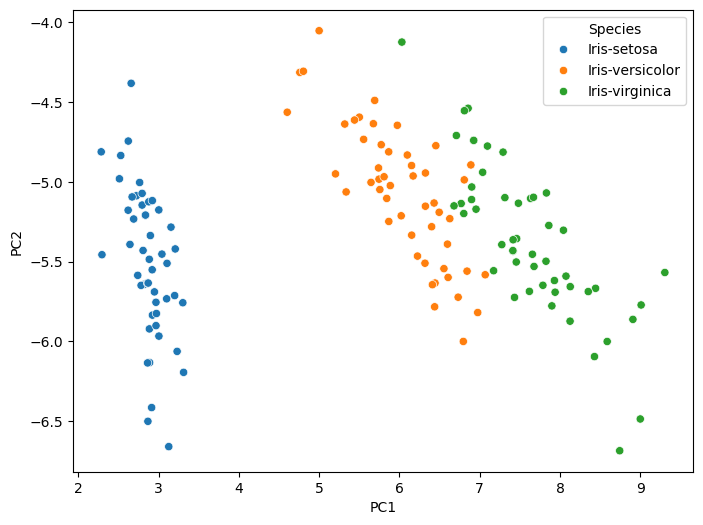

In [17]:
#Plotting PCs usnig SVD
plt.subplots(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Species', data=pc)
plt.show()

In [18]:
#Directly using PCA function from sklearn
# Choosing the extent of variance to be covered by the PCs
PCASklearn = PCA(n_components=0.95)
# Transforming the iris data input_columns
ProjectedDataSklearn= PCASklearn.fit_transform(irisData.iloc[:,:4])
# Storing the PCs in the data frame
ProjectedDataSklearnDf = pd.DataFrame(ProjectedDataSklearn,columns=['PC1','PC2'])

In [19]:
# Storing the PCs in the data frame along with class label
ProjectedDataSklearnDfWithClassInfo=pd.concat([ProjectedDataSklearnDf,
irisData.Species],axis=1)
print('Explained variance :\n')
print(PCASklearn.explained_variance_ratio_)

Explained variance :

[0.92461621 0.05301557]


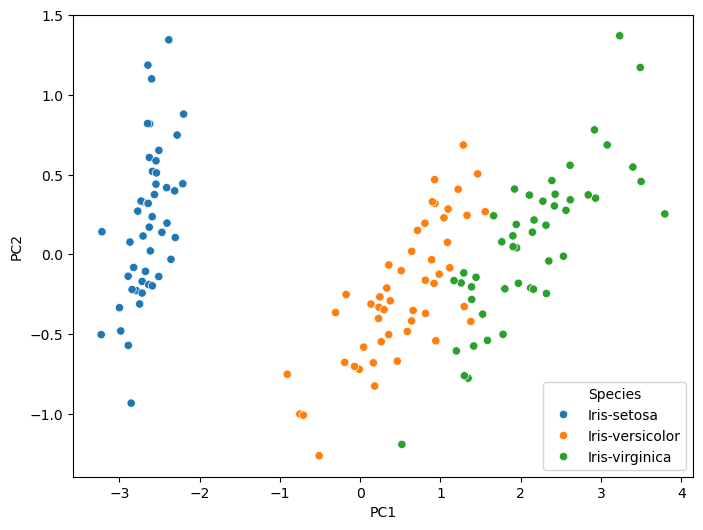

In [20]:
#Plotting PCs using direct PCA function values
plt.subplots(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Species', data=ProjectedDataSklearnDfWithClassInfo)
plt.show()